<a href="https://colab.research.google.com/github/Nhuyyyy3110/Stock_anomaly_detection/blob/main/04_feature_engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [11]:
from google.colab import files
import io
import pandas as pd

print("Vui lòng chọn tệp bạn muốn tải lên:")
uploaded = files.upload()

# Sau khi tải lên, bạn có thể đọc tệp vào DataFrame.
# Mã dưới đây giả định bạn tải lên một tệp CSV và sẽ cố gắng đọc tệp đầu tiên.
for filename in uploaded.keys():
  print(f'Bạn đã tải lên tệp "{filename}" với kích thước {len(uploaded[filename])} byte.')
  # Nếu tệp là CSV, chúng ta sẽ đọc nó.
  if filename.endswith('.csv'):
    try:
      # Chúng ta sử dụng io.StringIO để đọc nội dung tệp đã tải lên.
      # Đã thêm sep=';' để xử lý tệp CSV được phân tách bằng dấu chấm phẩy.
      df = pd.read_csv(io.StringIO(uploaded[filename].decode('utf-8')), sep=';')
      print(f"\nĐã đọc tệp '{filename}' vào DataFrame. Dưới đây là 5 dòng đầu tiên:")
      print(df.head())
    except Exception as e:
      print(f"Không thể đọc tệp CSV '{filename}': {e}")
  else:
    print(f"Tệp '{filename}' không phải là CSV. Vui lòng điều chỉnh mã để đọc định dạng tệp của bạn.")
  break # Chỉ xử lý tệp đầu tiên để đơn giản hóa ví dụ này.

Vui lòng chọn tệp bạn muốn tải lên:


Saving stock_clean.csv to stock_clean (2).csv
Bạn đã tải lên tệp "stock_clean (2).csv" với kích thước 372147 byte.

Đã đọc tệp 'stock_clean (2).csv' vào DataFrame. Dưới đây là 5 dòng đầu tiên:
  ticker        date   open   high    low  close   volume  \
0    ANV  2025-05-05  14.76  14.81  14.76  14.81   426000   
1    ANV  2025-05-06  13.99  15.20  13.79  15.20  3802000   
2    ANV  2025-05-07  15.10  15.30  14.76  15.25   686800   
3    ANV  2025-05-08  15.25  15.25  14.76  15.10  1323000   
4    ANV  2025-05-09  15.00  15.00  14.09  14.62  1977000   

                    crawl_timestamp  
0  2026-09-04 09:15:08.321000+00:00  
1  2026-09-04 09:15:08.321000+00:00  
2  2026-09-04 09:15:08.321000+00:00  
3  2026-09-04 09:15:08.321000+00:00  
4  2026-09-04 09:15:08.321000+00:00  


In [12]:
stock = pd.read_csv('/content/stock_clean (1).csv', sep=';')
stock.head()

,ticker,date,open,high,low,close,volume,crawl_timestamp
0,ANV,2025-05-05,14.76,14.81,14.76,14.81,426000,2026-09-04 09:15:08.321000+00:00
1,ANV,2025-05-06,13.99,15.20,13.79,15.20,3802000,2026-09-04 09:15:08.321000+00:00
2,ANV,2025-05-07,15.10,15.30,14.76,15.25,686800,2026-09-04 09:15:08.321000+00:00
3,ANV,2025-05-08,15.25,15.25,14.76,15.10,1323000,2026-09-04 09:15:08.321000+00:00
4,ANV,2025-05-09,15.00,15.00,14.09,14.62,1977000,2026-09-04 09:15:08.321000+00:00


In [13]:
stock.shape

(4690, 8)

In [15]:
stock["ticker"].nunique()

14

In [17]:
stock["ticker"].unique()

array(['ANV', 'DBC', 'DGW', 'DHG', 'FRT', 'IMP', 'MSN', 'MWG', 'PNJ',
       'QNS', 'SAB', 'SBT', 'VHC', 'VNM'], dtype=object)

In [19]:
stock["date"] = pd.to_datetime(stock["date"])

stock = stock.sort_values(
    ["ticker", "date"]
).reset_index(drop=True)

In [21]:
stock[stock["ticker"] == "MWG"].head()

,ticker,date,open,high,low,close,volume,crawl_timestamp
2345,MWG,2025-05-05,59.12,59.21,59.02,59.21,5099700,2026-09-04 09:14:53.802000+00:00
2346,MWG,2025-05-06,59.21,59.40,58.34,58.73,4110300,2026-09-04 09:14:53.802000+00:00
2347,MWG,2025-05-07,58.14,58.73,57.37,58.34,7742800,2026-09-04 09:14:53.802000+00:00
2348,MWG,2025-05-08,58.34,58.53,57.17,58.53,9463100,2026-09-04 09:14:53.802000+00:00
2349,MWG,2025-05-09,58.53,59.21,58.34,58.63,4780000,2026-09-04 09:14:53.802000+00:00


In [25]:
stock["return"] = (
    stock.groupby("ticker")["close"]
    .pct_change()
)

In [26]:
stock[
    ["ticker", "date", "close", "return"]
].head(25)

,ticker,date,close,return
0,ANV,2025-05-05,14.81,NaN
1,ANV,2025-05-06,15.20,0.026334
2,ANV,2025-05-07,15.25,0.003289
3,ANV,2025-05-08,15.10,-0.009836
4,ANV,2025-05-09,14.62,-0.031788
5,ANV,2025-05-12,14.52,-0.006840
6,ANV,2025-05-13,14.71,0.013085
7,ANV,2025-05-14,14.62,-0.006118
8,ANV,2025-05-15,14.23,-0.026676
9,ANV,2025-05-16,14.62,0.027407


In [27]:
stock["abs_Return"] = stock["return"].abs()

In [28]:
stock[
    ["ticker", "date", "return", "abs_Return"]
].head(10)

,ticker,date,return,abs_Return
0,ANV,2025-05-05,NaN,NaN
1,ANV,2025-05-06,0.026334,0.026334
2,ANV,2025-05-07,0.003289,0.003289
3,ANV,2025-05-08,-0.009836,0.009836
4,ANV,2025-05-09,-0.031788,0.031788
5,ANV,2025-05-12,-0.006840,0.006840
6,ANV,2025-05-13,0.013085,0.013085
7,ANV,2025-05-14,-0.006118,0.006118
8,ANV,2025-05-15,-0.026676,0.026676
9,ANV,2025-05-16,0.027407,0.027407


In [30]:
stock["range"] = (
    (stock["high"] - stock["low"])
    / stock["open"]
)

In [32]:
stock[
    ["ticker", "date", "open", "high", "low", "range"]
].head(10)

,ticker,date,open,high,low,range
0,ANV,2025-05-05,14.76,14.81,14.76,0.003388
1,ANV,2025-05-06,13.99,15.20,13.79,0.100786
2,ANV,2025-05-07,15.10,15.30,14.76,0.035762
3,ANV,2025-05-08,15.25,15.25,14.76,0.032131
4,ANV,2025-05-09,15.00,15.00,14.09,0.060667
5,ANV,2025-05-12,14.71,14.76,14.23,0.036030
6,ANV,2025-05-13,14.91,15.15,14.71,0.029510
7,ANV,2025-05-14,14.71,14.81,14.47,0.023114
8,ANV,2025-05-15,14.67,14.67,13.60,0.072938
9,ANV,2025-05-16,14.23,14.62,14.23,0.027407


In [33]:
stock["Volume_Mean_20"] = (
    stock.groupby("ticker")["volume"]
    .transform(
        lambda x: x.shift(1).rolling(20).mean()
    )
)

In [34]:
stock["Volume_Std_20"] = (
    stock.groupby("ticker")["volume"]
    .transform(
        lambda x: x.shift(1).rolling(20).std()
    )
)

In [35]:
stock["Relative_Volume"] = (
    stock["volume"]
    / stock["Volume_Mean_20"]
)

In [36]:
stock["Volume_Z"] = (
    (stock["volume"] - stock["Volume_Mean_20"])
    / stock["Volume_Std_20"]
)

In [37]:
stock["Volatility_20"] = (
    stock.groupby("ticker")["return"]
    .transform(
        lambda x: x.shift(1).rolling(20).std()
    )
)

In [39]:
feature_cols = [
    "ticker",
    "date",
    "open",
    "high",
    "low",
    "close",
    "volume",
    "return",
    "abs_Return",
    "range",
    "Relative_Volume",
    "Volume_Z",
    "Volatility_20"
]

stock[feature_cols].head(30)

,ticker,date,open,high,low,close,volume,return,abs_Return,range,Relative_Volume,Volume_Z,Volatility_20
0,ANV,2025-05-05,14.76,14.81,14.76,14.81,426000,NaN,NaN,0.003388,NaN,NaN,NaN
1,ANV,2025-05-06,13.99,15.20,13.79,15.20,3802000,0.026334,0.026334,0.100786,NaN,NaN,NaN
2,ANV,2025-05-07,15.10,15.30,14.76,15.25,686800,0.003289,0.003289,0.035762,NaN,NaN,NaN
3,ANV,2025-05-08,15.25,15.25,14.76,15.10,1323000,-0.009836,0.009836,0.032131,NaN,NaN,NaN
4,ANV,2025-05-09,15.00,15.00,14.09,14.62,1977000,-0.031788,0.031788,0.060667,NaN,NaN,NaN
5,ANV,2025-05-12,14.71,14.76,14.23,14.52,1478100,-0.006840,0.006840,0.036030,NaN,NaN,NaN
6,ANV,2025-05-13,14.91,15.15,14.71,14.71,2421800,0.013085,0.013085,0.029510,NaN,NaN,NaN
7,ANV,2025-05-14,14.71,14.81,14.47,14.62,1240000,-0.006118,0.006118,0.023114,NaN,NaN,NaN
8,ANV,2025-05-15,14.67,14.67,13.60,14.23,3104100,-0.026676,0.026676,0.072938,NaN,NaN,NaN
9,ANV,2025-05-16,14.23,14.62,14.23,14.62,1264800,0.027407,0.027407,0.027407,NaN,NaN,NaN


In [40]:
stock[
    [
        "return",
        "abs_Return",
        "range",
        "Relative_Volume",
        "Volume_Z",
        "Volatility_20"
    ]
].replace([np.inf, -np.inf], np.nan).isna().sum()

,0
return,14
abs_Return,14
range,0
Relative_Volume,280
Volume_Z,280
Volatility_20,294


In [41]:
(stock["Volume_Std_20"] == 0).sum()

np.int64(0)

In [42]:
stock[
    [
        "return",
        "abs_Return",
        "range",
        "Relative_Volume",
        "Volume_Z",
        "Volatility_20"
    ]
].describe()

,return,abs_Return,range,Relative_Volume,Volume_Z,Volatility_20
count,4676.000000,4676.000000,4690.000000,4410.000000,4410.000000,4396.000000
mean,0.000465,0.012859,0.023992,1.030689,0.056759,0.017351
std,0.019334,0.014444,0.016008,0.825753,1.622551,0.008797
min,-0.069859,0.000000,0.000000,0.016038,-3.426162,0.001878
25%,-0.008441,0.002794,0.012728,0.604168,-0.775752,0.009902
50%,0.000000,0.008288,0.019819,0.848385,-0.318023,0.016910
75%,0.008131,0.017213,0.030666,1.208329,0.430229,0.023172
max,0.070399,0.070399,0.152295,25.406162,46.404083,0.058417


In [43]:
mwg = stock[
    stock["ticker"] == "MWG"
].copy()

In [44]:
mwg[
    [
        "date",
        "close",
        "volume",
        "return",
        "abs_Return",
        "range",
        "Relative_Volume",
        "Volume_Z",
        "Volatility_20"
    ]
].tail(30)

,date,close,volume,return,abs_Return,range,Relative_Volume,Volume_Z,Volatility_20
2650,2026-07-22,69.52,13474000,-0.069842,0.069842,0.071046,3.598541,6.516435,0.013731
2651,2026-07-23,70.40,9066200,0.012658,0.012658,0.065255,2.154979,1.839914,0.019817
2652,2026-07-24,66.96,3613700,-0.048864,0.048864,0.041588,0.806141,-0.305062,0.020172
2653,2026-07-27,62.33,7694800,-0.069146,0.069146,0.083173,1.740734,1.147451,0.021935
2654,2026-07-28,64.20,6958300,0.030002,0.030002,0.053242,1.515398,0.803488,0.025704
2655,2026-07-29,66.50,4613000,0.035826,0.035826,0.049231,0.973370,-0.042235,0.027264
2656,2026-07-30,69.80,8424500,0.049624,0.049624,0.072180,1.804586,1.263521,0.028104
2657,2026-07-31,69.90,4562900,0.001433,0.001433,0.028369,0.939332,-0.095403,0.030926
2658,2026-08-03,72.50,5091200,0.037196,0.037196,0.044286,1.034394,0.055183,0.030941
2659,2026-08-04,72.10,3706800,-0.005517,0.005517,0.020776,0.751934,-0.398607,0.032275


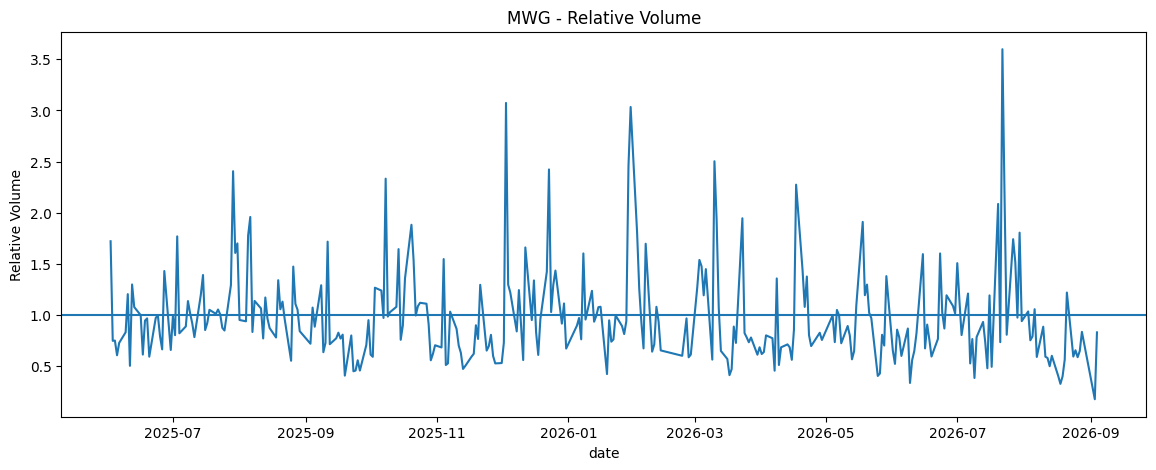

In [45]:
plt.figure(figsize=(14, 5))

plt.plot(
    mwg["date"],
    mwg["Relative_Volume"]
)

plt.axhline(1)

plt.xlabel("date")
plt.ylabel("Relative Volume")
plt.title("MWG - Relative Volume")

plt.show()

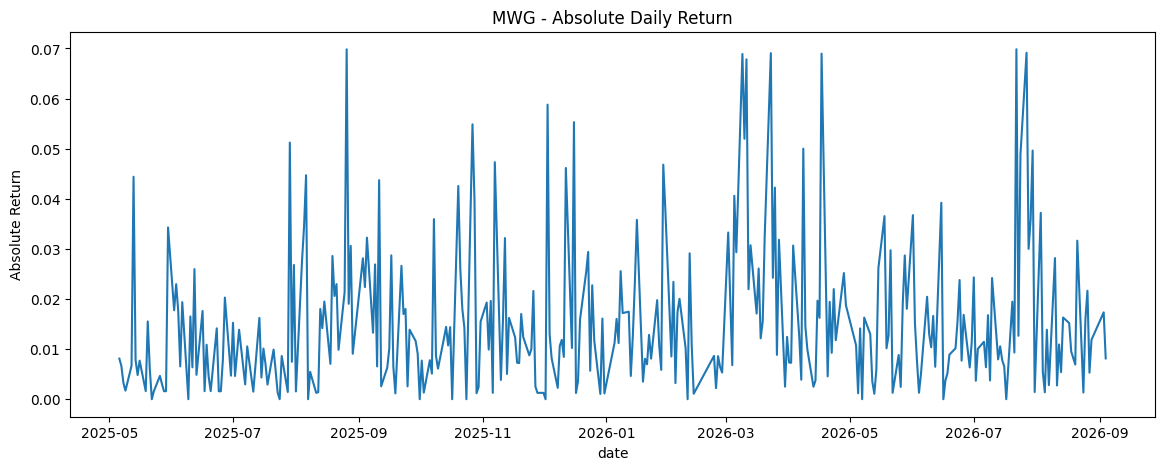

In [47]:
plt.figure(figsize=(14, 5))

plt.plot(
    mwg["date"],
    mwg["abs_Return"]
)

plt.xlabel("date")
plt.ylabel("Absolute Return")
plt.title("MWG - Absolute Daily Return")

plt.show()

In [49]:
import os

output_cols = [
    "ticker",
    "date",
    "open",
    "high",
    "low",
    "close",
    "volume",
    "return",
    "abs_Return",
    "range",
    "Volume_Mean_20",
    "Volume_Std_20",
    "Relative_Volume",
    "Volume_Z",
    "Volatility_20"
]

# Tạo thư mục nếu nó chưa tồn tại
output_dir = "../data/features"
os.makedirs(output_dir, exist_ok=True)

stock[output_cols].to_csv(
    os.path.join(output_dir, "stock_features.csv"),
    index=False
)

In [50]:
check = pd.read_csv(
    "../data/features/stock_features.csv"
)

check.head()

,ticker,date,open,high,low,close,volume,return,abs_Return,range,Volume_Mean_20,Volume_Std_20,Relative_Volume,Volume_Z,Volatility_20
0,ANV,2025-05-05,14.76,14.81,14.76,14.81,426000,NaN,NaN,0.003388,NaN,NaN,NaN,NaN,NaN
1,ANV,2025-05-06,13.99,15.20,13.79,15.20,3802000,0.026334,0.026334,0.100786,NaN,NaN,NaN,NaN,NaN
2,ANV,2025-05-07,15.10,15.30,14.76,15.25,686800,0.003289,0.003289,0.035762,NaN,NaN,NaN,NaN,NaN
3,ANV,2025-05-08,15.25,15.25,14.76,15.10,1323000,-0.009836,0.009836,0.032131,NaN,NaN,NaN,NaN,NaN
4,ANV,2025-05-09,15.00,15.00,14.09,14.62,1977000,-0.031788,0.031788,0.060667,NaN,NaN,NaN,NaN,NaN


In [51]:
check.shape

(4690, 15)

In [53]:
from google.colab import files

files.download("../data/features/stock_features.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>